### Building Chatbot With Multiple Tools Using Langgraph

#### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from langchain_core.tools import tool
from pydantic import BaseModel, Field


/var/folders/45/8w1pr1gj3_x84zm34y1vrkr00000gn/T/ipykernel_64405/1929659586.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun


In [2]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [3]:
import arxiv

# Force the client to use HTTPS
arxiv.Client.query_url_format = "https://export.arxiv.org/api/query?{}"

In [4]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

result = arxiv.invoke("Attention iss all you need")

arxiv


In [5]:
result

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [6]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [7]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation m'

In [8]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")



In [9]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

/var/folders/45/8w1pr1gj3_x84zm34y1vrkr00000gn/T/ipykernel_64405/3584238.py:4: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [10]:
tavily.invoke("Provide me the recent AI news for march 3rd 2025")

[{'title': 'The 10 Biggest AI News Stories Of 2025',
  'url': 'https://www.crn.com/news/ai/2025/the-10-biggest-ai-news-stories-of-2025',
  'content': 'Google announcing in March its plan to buy Wiz for $32 billion to boost AI capabilities in its security product portfolio\n ServiceNow unveiling in March its plan to buy Moveworks for about $3 billion to boost its AI assistant abilities\n IBM disclosing earlier this month its plan to buy Confluent for $11 billion to aid in AI deployment through the latter’s data streaming platform\n\nThe deals not only arm solution providers with AI products carrying more value from their vendor partners, they also open up new cross-selling and up-selling potential as each of these vendors integrate acquired assets into their existing portfolios.\n\n## Solution Providers Build AI Practices [...] # The 10 Biggest AI News Stories Of 2025\n\nThe AI industry in 2025 saw big-money acquisitions, advancements in virtual assistants and agent orchestration, and n

In [11]:
### Combine all the tools in the list

tools=[arxiv,wiki,tavily]

In [12]:
## Initialize my LLM model

from langchain_groq import ChatGroq

llm=ChatGroq(model="qwen/qwen3.6-27b")

llm_with_tools=llm.bind_tools(tools)

In [13]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'I need to find recent AI news.\nI will use the `tavily_search_results_json` tool to search for "recent AI news" or "latest AI news" to get up-to-date information.\nThen I will summarize the key findings for the user.\n', 'tool_calls': [{'id': 'p5fz9bkyn', 'function': {'arguments': '{"query":"recent AI news"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 88, 'prompt_tokens': 521, 'total_tokens': 609, 'completion_time': 0.167627483, 'completion_tokens_details': {'reasoning_tokens': 55}, 'prompt_time': 0.036932479, 'prompt_tokens_details': None, 'queue_time': 0.04737018, 'total_time': 0.204559962}, 'model_name': 'qwen/qwen3.6-27b', 'system_fingerprint': 'fp_3a782ca0f8', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ffbf6-fcc0-7fd3-ba57-a4080f12b726-0', tool_calls=[{'name': 'tavily_

In [14]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI news breakthroughs announcements last month'},
  'id': 'sn1aspq8j',
  'type': 'tool_call'}]

In [15]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage, SystemMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

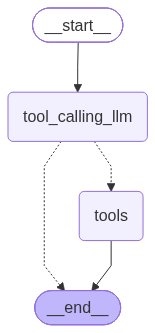

In [17]:
from IPython.display import display, Image
from langgraph.graph import START, END, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

### Node definition
def tool_calling_llm(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools=tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    #Adding Tools
    tools_condition
)
builder.add_edge("tools", END)

graph = builder.compile()
#View
display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
messages=graph.invoke({"messages":HumanMessage(content="Search arxiv for any one paper ")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Search arxiv for any one paper 
================================== Ai Message ==================================
Tool Calls:
  arxiv (1m28dtmb2)
 Call ID: 1m28dtmb2
  Args:
    query: deep learning
================================= Tool Message =================================
Name: arxiv

Published: 2023-06-24
Title: Learn to Accumulate Evidence from All Training Samples: Theory and Practice
Authors: Deep Pandey, Qi Yu
Summary: Evidential deep learning, built upon belief theory and subjective logic, offers a principled and computationally efficient way to turn a deterministic neural network uncertainty-aware. The resultant evidential models can quantify fine-grained uncertainty using the learned evidence. To ensure theoretically sound evidential models, the evidence needs to be n


In [19]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for MArch 3rd 2025")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 3rd 2025
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (j6jeshb5d)
 Call ID: j6jeshb5d
  Args:
    query: top AI news March 3 2025
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "March 2025: All AI updates from the past month", "url": "https://sdtimes.com/ai/march-2025-all-ai-updates-from-the-past-month", "content": "Skip to content\n\nSD Times\n\nSD Times\n\nLatest News\n\n# March 2025: All AI updates from the past month\n\nByJenna Barron\n\nSoftware companies are constantly trying to add more and more AI features to their platforms, and AI companies are constantly releasing new models and features. \n\nHere are all the major AI updates we covered in the month of March.\n\nGoogle releases reasoning model G

In [20]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (7tj9z3r71)
 Call ID: 7tj9z3r71
  Args:
    query: machine learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
Statistics and mathematical optimisation m
